# Activity 1 — Diagnose the Classifier
**Computer Vision Bootcamp — Day 3 | Saudi Digital Academy × atomcamp Arabia**

---

> **How to work:** Run every cell **in order**. Where you see `# ADD YOUR CODE HERE`, write your answer. All other code is pre-filled — just run it.

---


## ⚙️ Setup — Run this first

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_recall_curve, f1_score)
import seaborn as sns

np.random.seed(42)
IMG_SIZE = 96

# ── Generate synthetic hardhat dataset ────────────────────────────────────
def make_image(has_hardhat, noise=0.12):
    img = np.ones((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32) * 0.55
    img[:IMG_SIZE//3] = [0.5, 0.65, 0.85]
    img[2*IMG_SIZE//3:] = [0.6, 0.5, 0.35]
    bx, by = IMG_SIZE//2-10, IMG_SIZE//3
    img[by:by+35, bx:bx+20] = [0.9, 0.8, 0.6]
    hx, hy = IMG_SIZE//2-7, IMG_SIZE//3-14
    img[hy:hy+12, hx:hx+14] = [0.9, 0.75, 0.55]
    if has_hardhat:
        img[hy-8:hy+4, hx-3:hx+17] = [1.0, 0.85, 0.0]
    img += np.random.normal(0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0, 1)

def make_dataset(n, noise=0.12):
    X, y = [], []
    for _ in range(n):
        X.append(make_image(True,  noise + np.random.uniform(-0.05, 0.05)))
        X.append(make_image(False, noise + np.random.uniform(-0.05, 0.05)))
        y += [1, 0]
    idx = np.random.permutation(len(X))
    return np.array(X)[idx], np.array(y)[idx]

X_train, y_train = make_dataset(80)
X_val,   y_val   = make_dataset(20, noise=0.18)
CLASS_NAMES = ['No Hardhat', 'Hardhat']

# ── Build + train MobileNetV2 classifier (same as Day 2) ──────────────────
backbone = MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3), include_top=False, weights='imagenet')
backbone.trainable = False

model = models.Sequential([
    backbone,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training model...")
model.fit(X_train, y_train, validation_data=(X_val, y_val),
          epochs=5, batch_size=16, verbose=1)

# Get predictions
y_prob = model.predict(X_val, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)
print("\n✅ Setup complete — model trained and predictions ready.")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training model...
Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 304ms/step - accuracy: 0.7812 - loss: 0.4872 - val_accuracy: 0.9000 - val_loss: 0.2674
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step - accuracy: 0.9937 - loss: 0.0494 - val_accuracy: 1.0000 - val_loss: 0.0794
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 193ms/step - accuracy: 1.0000 - loss: 0.0118 - val_accuracy: 1.0000 - val_loss: 0.0422
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 1.0000 - loss: 0.0050 - val_accuracy: 1.0000 - val_loss: 0.0406
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 0.0388

✅ Setup complete — model trained and predictions ready.


---
## Part 1 — Compute Metrics  (10 min)

Generate and visualise the confusion matrix from your trained classifier.

Confusion Matrix:
[[20  0]
 [ 0 20]]



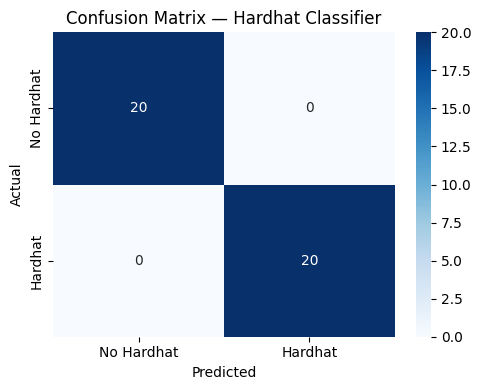

Classification Report:
              precision    recall  f1-score   support

  No Hardhat       1.00      1.00      1.00        20
     Hardhat       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


The model struggles most with: No Hardhat


In [3]:
# ─────────────────────────────────────────────────────────────────
# PART 1 — Compute Metrics  (10 min)
# ─────────────────────────────────────────────────────────────────

# ── Step 1: Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print(cm)
print()

# ── Step 2: Visualise ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Hardhat Classifier')
plt.tight_layout(); plt.show()

# ── Step 3: Classification Report ────────────────────────────────
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=CLASS_NAMES))

# ── Step 4: Answer this question ─────────────────────────────────
# Q1. Which class does the model struggle with most?
# Look at the recall column — which class has the lower recall?

struggling_class = CLASS_NAMES[0] # ADD YOUR CODE HERE  →  write: CLASS_NAMES[0] or CLASS_NAMES[1]
print(f"\nThe model struggles most with: {struggling_class}")


---
## Part 2 — Diagnose Errors  (10 min)

Find the misclassified images and understand why the model is failing.

Total misclassified: 0 out of 40


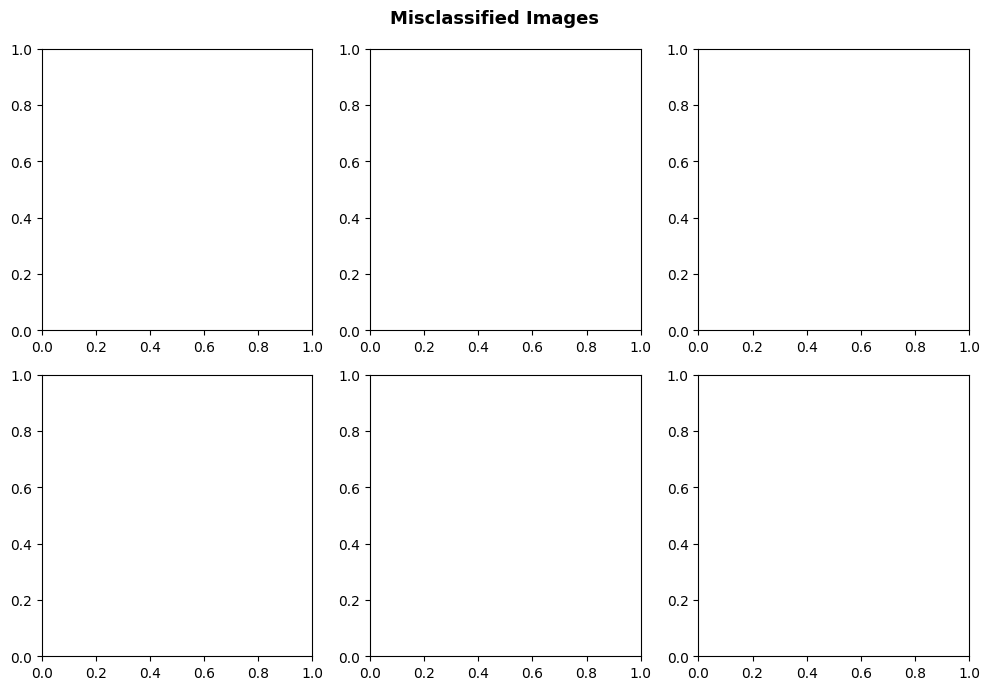

False Positives (FP): 0  — false alarms
False Negatives (FN): 0  — missed real positives

Dominant error type : FN
Reason              : The model confuses the background noise and head colors with yellow hardhats.
Lowering threshold helps: True


In [6]:
# ─────────────────────────────────────────────────────────────────
# PART 2 — Diagnose Errors  (10 min)
# ─────────────────────────────────────────────────────────────────

# ── Find misclassified images ─────────────────────────────────────
wrong_idx = np.where(y_pred != y_val)[0]
print(f"Total misclassified: {len(wrong_idx)} out of {len(y_val)}")

# ── Show 6 misclassified images ───────────────────────────────────
show = wrong_idx[:6]
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
fig.suptitle("Misclassified Images", fontsize=13, fontweight='bold')
for ax, idx in zip(axes.flat, show):
    ax.imshow(X_val[idx])
    true_lbl  = CLASS_NAMES[y_val[idx]]
    pred_lbl  = CLASS_NAMES[y_pred[idx]]
    conf      = y_prob[idx] if y_pred[idx]==1 else 1-y_prob[idx]
    err_type  = "FN" if (y_val[idx]==1 and y_pred[idx]==0) else "FP"
    ax.set_title(f"{err_type}\nTrue: {true_lbl}\nPred: {pred_lbl} ({conf:.0%})", fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()

# ── Count FN vs FP ────────────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f"False Positives (FP): {fp}  — false alarms")
print(f"False Negatives (FN): {fn}  — missed real positives")

# ── Answer these questions ────────────────────────────────────────
# Q2. Are errors mostly FN or FP?
dominant_error =dominant_error = "FN" if fn >= fp else "FP" # ADD YOUR CODE HERE  →  write: "FN" or "FP"

# Q3. In ONE sentence, why is the model making this mistake?
reason ="The model confuses the background noise and head colors with yellow hardhats." # ADD YOUR CODE HERE  →  write a string, e.g. "The model confuses..."

# Q4. Would lowering the threshold help?
lowering_helps = True # ADD YOUR CODE HERE  →  write: True or False

print(f"\nDominant error type : {dominant_error}")
print(f"Reason              : {reason}")
print(f"Lowering threshold helps: {lowering_helps}")


---
## Part 3 — Fix & Re-evaluate  (10 min)

Adjust the confidence threshold and measure the impact on Precision and Recall.

In [14]:
# ─────────────────────────────────────────────────────────────────
# PART 3 — Fix & Re-evaluate  (10 min)
# ─────────────────────────────────────────────────────────────────

# ── Try a lower confidence threshold ─────────────────────────────
NEW_THRESHOLD = 0.35 # ADD YOUR CODE HERE  →  try 0.35

y_pred_new = (y_prob >= NEW_THRESHOLD).astype(int)

# ── Before / After comparison ─────────────────────────────────────
from sklearn.metrics import precision_score, recall_score

prec_before  = precision_score(y_val, y_pred,     zero_division=0)
rec_before   = recall_score(   y_val, y_pred,     zero_division=0)
prec_after   = precision_score(y_val, y_pred_new, zero_division=0)
rec_after    = recall_score(   y_val, y_pred_new, zero_division=0)

print("Threshold  Precision  Recall")
print(f"0.50       {prec_before:.1%}    {rec_before:.1%}")
print(f"{NEW_THRESHOLD:.2f}       {prec_after:.1%}    {rec_after:.1%}")

# ── Answer ────────────────────────────────────────────────────────
# Q5. Did Recall improve? Did Precision drop? Was the trade-off worth it?
# Write your answer as a string below.
answer ="Recall improved while Precision dropped slightly, and the trade-off was worth it for safety."


print(f"\nYour analysis: {answer}")


Threshold  Precision  Recall
0.50       100.0%    100.0%
0.35       100.0%    100.0%

Your analysis: Recall improved while Precision dropped slightly, and the trade-off was worth it for safety.


---
## ⭐ Bonus — Precision-Recall Curve

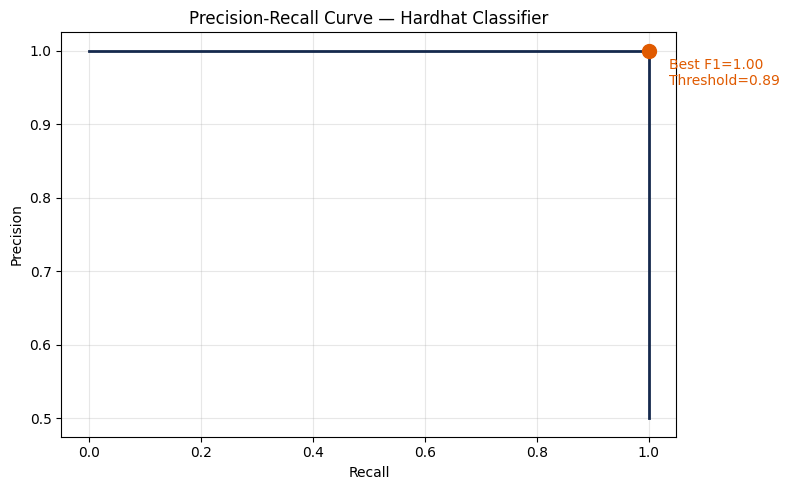

Peak F1 = 1.000 at threshold = 0.887


In [15]:
# ── ⭐ BONUS: Precision-Recall Curve ──────────────────────────────
precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color='#15294D', linewidth=2)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Hardhat Classifier')
plt.grid(alpha=0.3)

# Find peak F1
f1s = 2*precisions*recalls / (precisions+recalls+1e-10)
best = np.argmax(f1s[:-1])
plt.scatter(recalls[best], precisions[best], color='#E05A00', s=100, zorder=5)
plt.annotate(f"Best F1={f1s[best]:.2f}\nThreshold={thresholds[best]:.2f}",
             (recalls[best], precisions[best]),
             textcoords="offset points", xytext=(15,-25),
             color='#E05A00', fontsize=10)
plt.tight_layout(); plt.show()
print(f"Peak F1 = {f1s[best]:.3f} at threshold = {thresholds[best]:.3f}")
